In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import gc
import itertools

In [2]:
base_path = ""
which_file = "pairs"
which_chunk = "Chunk0950"
which_number = ["001_007"]
N_SPLITS = 10
file_names = [""]*N_SPLITS*len(which_number)
for num in range (len(which_number)):
    path = base_path + "_".join([which_file, which_chunk, which_number[num]])
    for i in range(N_SPLITS):
        file_names[i+N_SPLITS*num] = ( path + f"_{i}_v2.pkl" )
print(file_names)

bucket = []
for item in file_names:
    bucket.append( pd.read_pickle(item)  )
    
df = pd.concat(bucket, ignore_index=True)
 # Debug
print("The starting dataframe has", len(df), "rows and ", len(df.columns), "columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The starting dataframe occupies {memory:.2f} MB")
df.head()

['pairs_Chunk0950_001_007_0_v2.pkl', 'pairs_Chunk0950_001_007_1_v2.pkl', 'pairs_Chunk0950_001_007_2_v2.pkl', 'pairs_Chunk0950_001_007_3_v2.pkl', 'pairs_Chunk0950_001_007_4_v2.pkl', 'pairs_Chunk0950_001_007_5_v2.pkl', 'pairs_Chunk0950_001_007_6_v2.pkl', 'pairs_Chunk0950_001_007_7_v2.pkl', 'pairs_Chunk0950_001_007_8_v2.pkl', 'pairs_Chunk0950_001_007_9_v2.pkl']
The starting dataframe has 16096666 rows and  19 columns.
The starting dataframe occupies 1952.40 MB


,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,particle,pos_tof_ka,pos_tof_pi,neg_tof_ka,neg_tof_pi,pos_tpc_ka,pos_tpc_pi,neg_tpc_ka,neg_tpc_pi,pos_pt,neg_pt
0,0,-3.887406e-07,2.024925,2.004279,0.562010,0.217750,0.002837,0.119625,Undecided,-999.000000,-999.000000,-999.000000,-999.000000,0.336417,0.494370,-1.040863,0.494370,1.062110,0.884602
1,0,-1.776956e-05,1.630082,1.723747,1.006076,0.707632,0.014159,-0.858506,Anti-D0,2.731402,47.058315,-999.000000,-999.000000,1.979263,9.544146,0.791008,9.544146,0.537510,1.256379
2,0,4.085324e-05,2.030803,2.127274,0.937323,-0.326464,0.043936,-0.960780,Anti-D0,2.731402,47.058315,-999.000000,-999.000000,1.979263,9.544146,1.920502,9.544146,0.537510,1.416420
3,1,-1.104787e-07,1.760064,1.715242,0.871433,0.458262,0.002074,-0.685242,Anti-D0,-999.000000,-999.000000,-999.000000,-999.000000,-1.024736,-1.022218,-3.238938,-1.022218,1.109283,0.627794
4,2,3.436724e-05,1.549974,1.626505,0.808844,0.310051,0.013418,-0.396651,Undecided,-999.000000,-999.000000,-15.667806,1.188701,-3.839797,1.757079,-1.110457,1.757079,0.516561,0.915982


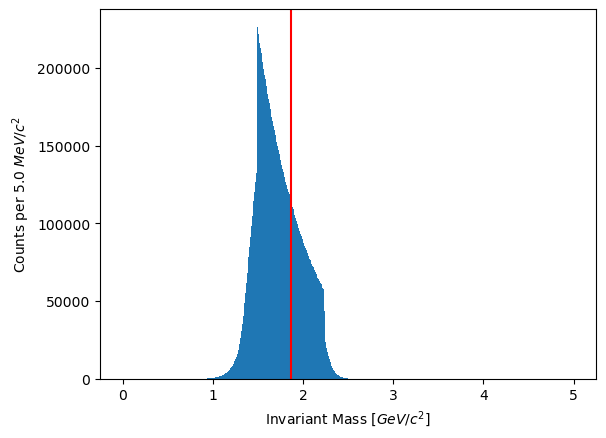

In [3]:
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

# Variables for Plot
MIN_MASS = 0
MAX_MASS = 5
N_BINS = int(1e+03)

masses = np.concatenate([df[df["particle"]=="D0"]["inv_mass"], df[df["particle"]=="Anti-D0"]["anti_mass"],
                         df[df["particle"]=="Undecided"]["inv_mass"], df[df["particle"]=="Undecided"]["anti_mass"]])

# Dummy plot: this takes the same collision index multiple times, with no filtering.
plt.hist(masses, range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000)} $MeV/c^2$")
plt.show()

In [4]:
df.columns

Index(['collision_index', 'dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'pz',
       'decay_length', 'cos_pointing', 'particle', 'pos_tof_ka', 'pos_tof_pi',
       'neg_tof_ka', 'neg_tof_pi', 'pos_tpc_ka', 'pos_tpc_pi', 'neg_tpc_ka',
       'neg_tpc_pi', 'pos_pt', 'neg_pt'],
      dtype='object')

In [ ]:
new_Ka_hyp_neg =  (  df["neg_tpc_ka"].abs() < 2 ) & \
            ( ( (df["neg_pt"].between(0, 1.4)) & (df["neg_tof_ka"].abs() < 4) ) |
              ( (df["neg_pt"].between(1.4, 2.0)) & (df["neg_tof_ka"].abs() < 2) ) |
              ( (df["neg_pt"].between(0, 2.0)) & (df["neg_tof_ka"]==-999) )
            )

new_Ka_hyp_pos =  (  df["pos_tpc_ka"].abs() < 2 ) & \
            ( ( (df["pos_pt"].between(0, 1.4)) & (df["pos_tof_ka"].abs() < 4) ) |
              ( (df["pos_pt"].between(1.4, 2.0)) & (df["pos_tof_ka"].abs() < 2) ) |
              ( (df["pos_pt"].between(0, 2.0)) & (df["pos_tof_ka"]==-999) )
            )

new_Pi_hyp_neg =  (  df["neg_tpc_pi"].abs() < 2 ) & \
            ( ( (df["neg_pt"].between(0, 1.4)) & (df["neg_tof_pi"].abs() < 4) ) |
              ( (df["neg_pt"].between(1.4, 2.0)) & (df["neg_tof_pi"].abs() < 2) ) |
              ( (df["neg_pt"].between(0, 2.0)) & (df["neg_tof_pi"]==-999) )
            )

new_Pi_hyp_pos =  (  df["pos_tpc_pi"].abs() < 2 ) & \
            ( ( (df["pos_pt"].between(0, 1.4)) & (df["pos_tof_pi"].abs() < 4) ) |
              ( (df["pos_pt"].between(1.4, 2.0)) & (df["pos_tof_pi"].abs() < 2) ) |
              ( (df["pos_pt"].between(0, 2.0)) & (df["pos_tof_pi"]==-999) )
            )

new_undecided_neg = new_Ka_hyp_neg & new_Pi_hyp_neg
new_undecided_pos = new_Ka_hyp_pos & new_Pi_hyp_pos
new_undecided_hyp = new_undecided_neg & new_undecided_pos

new_Ka_hyp = new_Ka_hyp_neg | new_Ka_hyp_pos
new_Pi_hyp = new_Pi_hyp_pos | new_Pi_hyp_neg

new_D0_sure_hyp = new_Ka_hyp_neg & new_Pi_hyp_pos
new_D0_uncert_hyp = ( (new_undecided_neg & new_Pi_hyp_pos) | (new_undecided_pos & new_Ka_hyp_neg) )
new_D0 = new_D0_sure_hyp | new_D0_uncert_hyp

new_antiD0_sure_hyp = new_Ka_hyp_pos & new_Pi_hyp_neg
new_antiD0_uncert_hyp = ( (new_undecided_neg & new_Ka_hyp_pos) | (new_undecided_pos & new_Pi_hyp_neg) )
new_antiD0 = new_antiD0_sure_hyp | new_antiD0_uncert_hyp

df["new_particle"] = np.select( condlist=[new_undecided_hyp, new_D0, new_antiD0 ],
                                choicelist=["Undecided", "D0", "AntiD0"], default="Bkg" )

In [ ]:
# Now with some filtering
COS_CUT = 0.90
PT_MIN, PT_MAX = 2, 8                                  # +infinity is np.inf
MASS_MIN, MASS_MAX = 0, 5
DCA_CUT = 3e-03
N_BINS = 100

mask = (df["cos_pointing"] > 0.96) & (df["dcaXY_product"]< +3e-06) & ( df["pt"].between(2,8) )
filtered_df = df[mask]

filtered_masses = np.concatenate([filtered_df[filtered_df["new_particle"]=="D0"]["inv_mass"],
                                  filtered_df[filtered_df["new_particle"]=="Anti-D0"]["anti_mass"],
                                  filtered_df[filtered_df["new_particle"]=="Undecided"]["inv_mass"],
                                  filtered_df[filtered_df["new_particle"]=="Undecided"]["anti_mass"]])


fig, ax = plt.subplots(1,2, figsize=(21,9) )
ax[0].hist(filtered_masses,range=(MASS_MIN,MASS_MAX), bins=N_BINS)
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {((MASS_MAX-MASS_MIN)/N_BINS *1000):.1f} $MeV/c^2$")
ax[0].set_title(f"Invariant mass")

M_min, M_max = 0.9, 1.1
N_bins = 100
ax[1].hist(filtered_masses,range=(m_d0*M_min,m_d0*M_max), bins=N_bins)
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax[1].set_title(f"Invariant mass")
plt.show()